## Global COVID-19 Analytics

### Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Preparing dataset

In [2]:
df = pd.read_csv('country_wise_latest.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [5]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [6]:
df.isnull().sum()

,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


In [7]:
df.duplicated().sum()

np.int64(0)

## Growth rate analysis

In [16]:
## countries with highest number of confirmed cases
df.sort_values(by='Confirmed', ascending=False).head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,1_week_growth_rate
173,US,4290259,148011,1325804,2816444,56336,1076,27941,3.45,30.90,11.16,3834677,455582,11.88,Americas,842779.960707
23,Brazil,2442375,87618,1846641,508116,23284,614,33728,3.59,75.61,4.74,2118646,323729,15.28,Americas,3576.725176
79,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,3.51,1155338,324735,28.11,South-East Asia,75645.803480
138,Russia,816680,13334,602249,201097,5607,85,3077,1.63,73.74,2.21,776212,40468,5.21,Europe,17856.904134
154,South Africa,452529,7067,274925,170537,7096,298,9848,1.56,60.75,2.57,373628,78901,21.12,Africa,1774.524668
111,Mexico,395489,44022,303810,47657,4973,342,8588,11.13,76.82,14.49,349396,46093,13.19,Americas,10693.913755
132,Peru,389717,18418,272547,98752,13756,575,4697,4.73,69.93,6.76,357681,32036,8.96,Americas,3715.891511
35,Chile,347923,9187,319954,18782,2133,75,1859,2.64,91.96,2.87,333029,14894,4.47,Americas,91943.121693
177,United Kingdom,301708,45844,1437,254427,688,7,3,15.19,0.48,3190.26,296944,4764,1.60,Europe,203756.756757
81,Iran,293606,15912,255144,22550,2434,212,1931,5.42,86.90,6.24,276202,17404,6.30,Eastern Mediterranean,3900.081744


In [14]:
## average 1 week % increase by WHO region
df.groupby('WHO Region')['1 week % increase'].mean().sort_values(ascending=False)


,1 week % increase
WHO Region,
Western Pacific,22.111250
Africa,18.086458
Americas,16.331143
Eastern Mediterranean,10.482273
South-East Asia,8.513000
Europe,7.769643


## Country-wise Statistics

In [18]:
## country wise Statistics
## country wise recovery rate

df['Recovery Rate'] = (df['Recovered'] / df['Confirmed']) * 100

df.head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,1_week_growth_rate,Recovery Rate
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,0.000000,69.486805
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,0.000000,56.250000
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,0.000000,67.339935
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,0.000000,88.533627
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,0.000000,25.473684
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas,0.000000,75.581395
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas,0.000000,43.350098
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe,3.107851,71.315860
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific,213.586066,60.844279
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe,-26.507704,88.753770


## Trend Analysis

<Axes: xlabel='Country/Region', ylabel='Confirmed'>

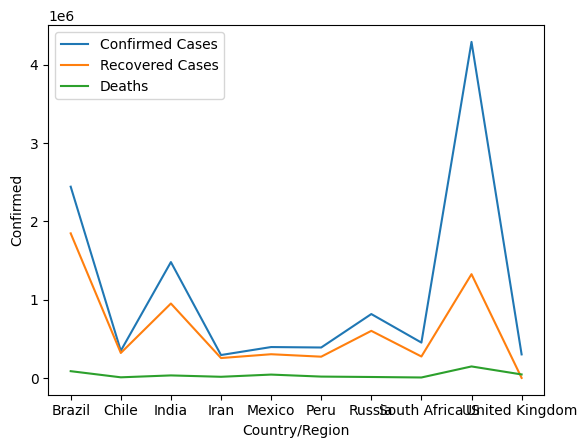

In [21]:
# Trend Analysis using line plot for confirmed cases, deaths and recovered cases of top 10 countries with highest confirmed cases

top_10_countries = df.groupby('Country/Region').sum().sort_values('Confirmed', ascending=False).head(10).index
df_top_10 = df[df['Country/Region'].isin(top_10_countries)]

sns.lineplot(data=df_top_10, x='Country/Region', y='Confirmed', label='Confirmed Cases')
sns.lineplot(data=df_top_10, x='Country/Region', y='Recovered', label='Recovered Cases')
sns.lineplot(data=df_top_10, x='Country/Region', y='Deaths', label='Deaths')

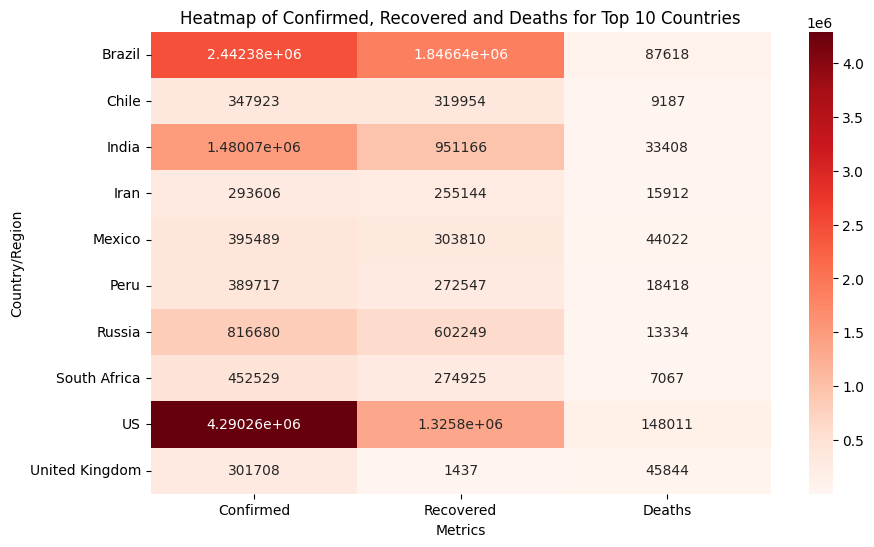

In [23]:
# Heatmap for confirmed, recovered, and deaths of top 10 countries

# Determine top 10 countries by confirmed cases
top_10_countries = df.groupby('Country/Region').sum().sort_values('Confirmed', ascending=False).head(10).index
df_top_10 = df[df['Country/Region'].isin(top_10_countries)]

# Aggregate numeric metrics by country (snapshot dataset has no Date column)
df_agg = df_top_10.groupby('Country/Region')[['Confirmed', 'Recovered', 'Deaths']].sum()

plt.figure(figsize=(10, 6))
sns.heatmap(df_agg, cmap='Reds', annot=True, fmt='g')
plt.title('Heatmap of Confirmed, Recovered and Deaths for Top 10 Countries')
plt.xlabel('Metrics')
plt.ylabel('Country/Region')
plt.show()